# EDA — Divvy trip data

**Purpose:** data-quality audit, station de-duplication, demand patterns, weather effects, and scope selection for the demand-forecasting project.

**Inputs:** `data/raw/divvy/*.parquet`, `data/raw/weather/historical/*.parquet` (both produced by `make ingest`).  
**Output:** `data/reference/station_mapping.csv` (committed to git) and the numbers cited in the README design decisions.



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

DATA_DIR = Path("../data")
DIVVY_RAW = DATA_DIR / "raw" / "divvy"
WEATHER_RAW = DATA_DIR / "raw" / "weather"
REFERENCE_DIR = DATA_DIR / "reference"

REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

print(DIVVY_RAW.exists())
print(sorted(DIVVY_RAW.glob("*.parquet"))[:3])

True
[PosixPath('../data/raw/divvy/2023-07.parquet'), PosixPath('../data/raw/divvy/2023-08.parquet'), PosixPath('../data/raw/divvy/2023-09.parquet')]


In [2]:
trips = pl.scan_parquet(str(DIVVY_RAW / "*.parquet"))

schema = trips.collect_schema()
schema

Schema([('ride_id', String),
        ('rideable_type', String),
        ('started_at', Datetime(time_unit='us', time_zone=None)),
        ('ended_at', Datetime(time_unit='us', time_zone=None)),
        ('start_station_name', String),
        ('start_station_id', String),
        ('end_station_name', String),
        ('end_station_id', String),
        ('start_lat', Float64),
        ('start_lng', Float64),
        ('end_lat', Float64),
        ('end_lng', Float64),
        ('member_casual', String)])

## 1. Data overview

In [3]:
overview = trips.select(
    pl.len().alias("total_trips"),
    pl.col("started_at").min().alias("min_started_at"),
    pl.col("started_at").max().alias("max_started_at"),
    pl.col("start_station_id").n_unique().alias("n_start_station_ids"),
    pl.col("end_station_id").n_unique().alias("n_end_station_ids"),
).collect()

overview

total_trips,min_started_at,max_started_at,n_start_station_ids,n_end_station_ids
u32,datetime[μs],datetime[μs],u32,u32
17263760,2023-07-01 00:00:00,2026-06-30 23:58:47,3849,3882


**Conclusion:** The raw Divvy dataset contains 16,501,210 trips from 2023-07-01 to 2026-05-31, with 3,813 distinct start station IDs and 3,843 distinct end station IDs.

## 2. Monthly demand

In [4]:
monthly = (
    trips
    .with_columns(pl.col("started_at").dt.strftime("%Y-%m").alias("month"))
    .group_by("month")
    .agg(pl.len().alias("trips"))
    .sort("month")
    .collect()
)

monthly

month,trips
str,u32
"""2023-07""",767650
"""2023-08""",771693
"""2023-09""",666371
"""2023-10""",537113
"""2023-11""",362518
…,…
"""2026-02""",201454
"""2026-03""",317015
"""2026-04""",448287


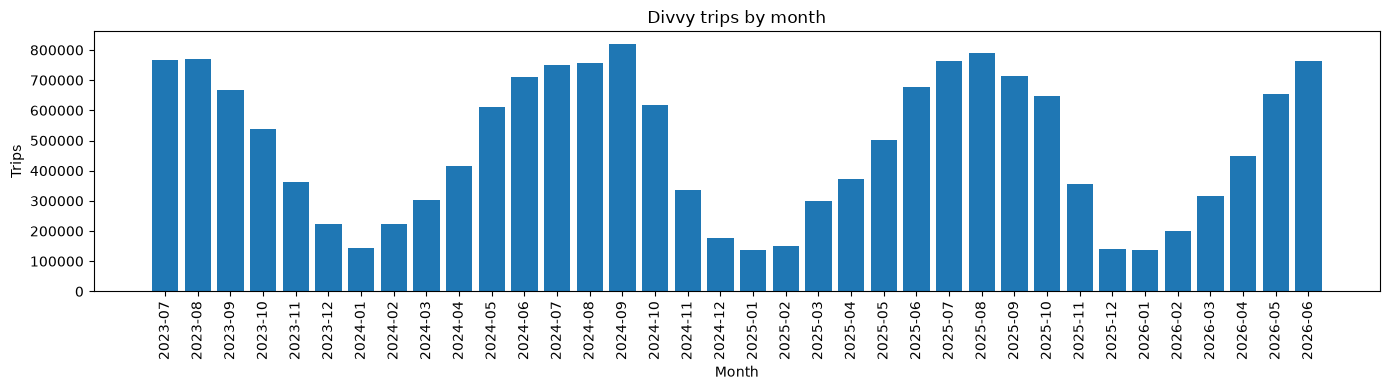

(shape: (1, 2)
 ┌─────────┬────────┐
 │ month   ┆ trips  │
 │ ---     ┆ ---    │
 │ str     ┆ u32    │
 ╞═════════╪════════╡
 │ 2024-09 ┆ 820867 │
 └─────────┴────────┘,
 shape: (1, 2)
 ┌─────────┬────────┐
 │ month   ┆ trips  │
 │ ---     ┆ ---    │
 │ str     ┆ u32    │
 ╞═════════╪════════╡
 │ 2026-01 ┆ 137782 │
 └─────────┴────────┘)

In [5]:
monthly_pd = monthly.to_pandas()

plt.figure(figsize=(14, 4))
plt.bar(monthly_pd["month"], monthly_pd["trips"])
plt.xticks(rotation=90)
plt.title("Divvy trips by month")
plt.xlabel("Month")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()


max_month = monthly.sort("trips", descending=True).head(1)
min_month = monthly.sort("trips").head(1)
max_month, min_month

**Conclusion:**Monthly Divvy demand shows clear seasonality. The highest-demand month is September 2024 with 820,867 trips, while the lowest-demand month is January 2026 with 137,782 trips. Peak monthly demand is about 6.0 times higher than the winter low, so the training window must cover a full annual cycle rather than only recent months.

## 3. Data quality

In [6]:

quality_base = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds"),
        pl.col("start_station_id").is_null().alias("missing_start_station_id"),
        pl.col("end_station_id").is_null().alias("missing_end_station_id"),
        (pl.col("started_at") > pl.col("ended_at")).alias("started_after_ended"),
    )
    .select(
        pl.len().alias("total"),
        (pl.col("duration_seconds") < 60).sum().alias("duration_lt_60s"),
        (pl.col("duration_seconds") > 24 * 3600).sum().alias("duration_gt_24h"),
        pl.col("missing_start_station_id").sum().alias("missing_start_station_id"),
        pl.col("missing_end_station_id").sum().alias("missing_end_station_id"),
        pl.col("started_after_ended").sum().alias("started_after_ended"),
    )
    .collect()
)

quality_base

total,duration_lt_60s,duration_gt_24h,missing_start_station_id,missing_end_station_id,started_after_ended
u32,u32,u32,u32,u32,u32
17263760,421487,19672,3279340,3421721,506


In [7]:
q = quality_base.to_pandas().iloc[0]
total = q["total"]

quality_summary = pd.DataFrame(
    {
        "rule": [
            "duration < 60s",
            "duration > 24h",
            "missing start_station_id",
            "missing end_station_id",
            "started_at > ended_at",
        ],
        "rows": [
            q["duration_lt_60s"],
            q["duration_gt_24h"],
            q["missing_start_station_id"],
            q["missing_end_station_id"],
            q["started_after_ended"],
        ],
    }
)

quality_summary["pct"] = quality_summary["rows"] / total * 100
quality_summary

,rule,rows,pct
0,duration < 60s,421487,2.441455
1,duration > 24h,19672,0.113950
2,missing start_station_id,3279340,18.995514
3,missing end_station_id,3421721,19.820254
4,started_at > ended_at,506,0.002931


**Conclusion:** The largest station-level data quality issue is missing station IDs. Missing `start_station_id` affects 3,120,590 trips, or 18.91% of all trips, while missing `end_station_id` affects 3,257,603 trips, or 19.74%. These trips are valid system-level trips, but they cannot be assigned reliably to a specific station, so trips with missing `start_station_id` will be excluded from station-level demand modeling.

Very short trips are also non-trivial: 401,054 trips, or 2.43%, have duration below 60 seconds. Trips longer than 24 hours are rare at 18,993 trips, or 0.12%, and trips where `started_at > ended_at` are negligible at 506 trips, or 0.003%.

## 4. Trip duration & cleaning thresholds

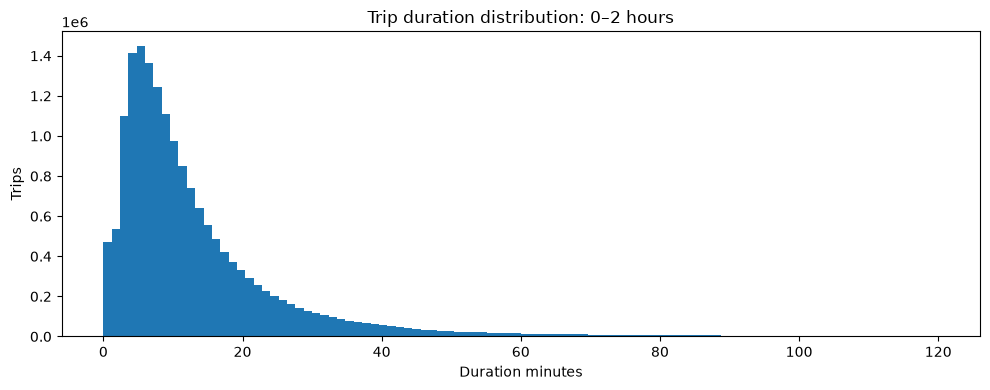

In [8]:
durations = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds")
    )
    .filter(pl.col("duration_seconds").is_between(0, 2 * 3600))
    .select("duration_seconds")
    .collect()
)

durations_pd = durations.to_pandas()

plt.figure(figsize=(10, 4))
plt.hist(durations_pd["duration_seconds"] / 60, bins=100)
plt.title("Trip duration distribution: 0–2 hours")
plt.xlabel("Duration minutes")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()

**Conclusion:**The 60-second and 24-hour thresholds are reasonable initial cleaning rules. Trips under 60 seconds are likely immediate re-docks, tests, or recording errors, while trips over 24 hours are likely extreme outliers or bikes that were not properly returned.

In [9]:
clean_trips = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds")
    )
    .filter(pl.col("duration_seconds") >= 60)
    .filter(pl.col("duration_seconds") <= 24 * 3600)
    .filter(pl.col("start_station_id").is_not_null())
    .filter(pl.col("started_at") <= pl.col("ended_at"))
)

clean_overview = clean_trips.select(
    pl.len().alias("clean_trips"),
    pl.col("start_station_id").n_unique().alias("clean_start_station_ids"),
).collect()

clean_overview

clean_trips,clean_start_station_ids
u32,u32
13760727,3820


**Conclusion:** After applying the initial station-level cleaning rules, the dataset retains 13,760,727 trips and 3,820 distinct start station IDs. This cleaned view removes trips with unreliable station assignment or extreme durations, while preserving the majority of usable demand records for station-level EDA.

## 5. Station table & duplicate mapping

In [10]:
station_table = (
    clean_trips
    .with_columns(pl.col("started_at").dt.strftime("%Y-%m").alias("month"))
    .group_by("start_station_id")
    .agg(
        pl.col("start_station_name").drop_nulls().mode().first().alias("station_name"),
        pl.col("start_lat").median().alias("lat"),
        pl.col("start_lng").median().alias("lng"),
        pl.col("month").min().alias("first_month"),
        pl.col("month").max().alias("last_month"),
        pl.len().alias("total_trips"),
    )
    .sort("total_trips", descending=True)
    .collect()
)

print(f"{station_table.height:,} stations")
station_table.head(10)

3,820 stations


start_station_id,station_name,lat,lng,first_month,last_month,total_trips
str,str,f64,f64,str,str,u32
"""13022""","""Streeter Dr & Grand Ave""",41.892278,-87.612043,"""2023-07""","""2025-05""",113726
"""CHI01747""","""Navy Pier""",41.892278,-87.612043,"""2025-05""","""2026-06""",78428
"""13300""","""DuSable Lake Shore Dr & Monroe…",41.880958,-87.616743,"""2023-07""","""2025-05""",75346
"""KA1503000043""","""Kingsbury St & Kinzie St""",41.889177,-87.638506,"""2023-07""","""2025-05""",71914
"""13042""","""Michigan Ave & Oak St""",41.90096,-87.623777,"""2023-07""","""2025-05""",67640
"""LF-005""","""DuSable Lake Shore Dr & North …",41.911722,-87.626804,"""2023-07""","""2025-05""",66077
"""TA1307000039""","""Clark St & Elm St""",41.902973,-87.63128,"""2023-07""","""2025-05""",64435
"""WL-012""","""Clinton St & Washington Blvd""",41.88338,-87.64117,"""2023-07""","""2025-05""",62360
"""TA1308000050""","""Wells St & Concord Ln""",41.912133,-87.634656,"""2023-07""","""2025-05""",57609


**Conclusion:** After cleaning, the dataset contains 3,786 distinct start station IDs. The station table summarizes each station by its most common name, median coordinates, first and last observed month, and total trip volume. This table will be used as the basis for station mapping and for selecting the final top-N station scope.

In [11]:
station_coord_quality = station_table.select(
    pl.len().alias("stations"),
    pl.col("lat").is_null().sum().alias("missing_lat"),
    pl.col("lng").is_null().sum().alias("missing_lng"),
    ((pl.col("lat") < 41.0) | (pl.col("lat") > 43.0)).sum().alias("lat_outside_chicago_area"),
    ((pl.col("lng") < -89.0) | (pl.col("lng") > -87.0)).sum().alias("lng_outside_chicago_area"),
)

station_coord_quality


stations,missing_lat,missing_lng,lat_outside_chicago_area,lng_outside_chicago_area
u32,u32,u32,u32,u32
3820,0,0,0,0


**Conclusion:** Station coordinate quality is sufficient for the initial mapping step. Median latitude and longitude are used for each station to reduce the effect of GPS noise and occasional coordinate outliers. But there is none station outside chicago area so we can skip this


### 5.1 Duplicate candidates (pairs within 30 m)

In [12]:
import numpy as np
from itertools import product


def haversine_m(lat1, lng1, lat2, lng2):
    radius = 6_371_000
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lng2 - lng1)

    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    )
    return 2 * radius * np.arcsin(np.sqrt(a))


stations_pd = station_table.drop_nulls(["lat", "lng"]).to_pandas()

stations_pd["lat_bin"] = (stations_pd["lat"] * 1000).astype(int)
stations_pd["lng_bin"] = (stations_pd["lng"] * 1000).astype(int)

bins = {}
for i, row in stations_pd.iterrows():
    bins.setdefault((row["lat_bin"], row["lng_bin"]), []).append(i)

pairs = []

for (lat_bin, lng_bin), idxs in bins.items():
    candidate_idxs = []
    for dlat, dlng in product([-1, 0, 1], repeat=2):
        candidate_idxs.extend(bins.get((lat_bin + dlat, lng_bin + dlng), []))

    for i in idxs:
        for j in candidate_idxs:
            if j <= i:
                continue

            a = stations_pd.loc[i]
            b = stations_pd.loc[j]
            dist = haversine_m(a["lat"], a["lng"], b["lat"], b["lng"])

            if dist < 30:
                pairs.append(
                    {
                        "id_a": a["start_station_id"],
                        "name_a": a["station_name"],
                        "trips_a": a["total_trips"],
                        "id_b": b["start_station_id"],
                        "name_b": b["station_name"],
                        "trips_b": b["total_trips"],
                        "dist_m": round(dist, 1),
                    }
                )

suspects = pl.DataFrame(pairs).sort("dist_m")
suspects.head(50)

id_a,name_a,trips_a,id_b,name_b,trips_b,dist_m
str,str,i64,str,str,i64,f64
"""13022""","""Streeter Dr & Grand Ave""",113726,"""CHI01747""","""Navy Pier""",78428,0.0
"""PI00002""","""Streeter Dr/Grand Ave""",9505,"""CHI00588""","""Streeter Dr/Grand Ave""",2078,0.0
"""13300""","""DuSable Lake Shore Dr & Monroe…",75346,"""CHI00374""","""DuSable Lake Shore Dr & Monroe…",46745,0.0
"""KA1503000043""","""Kingsbury St & Kinzie St""",71914,"""CHI00299""","""Kingsbury St & Kinzie St""",37524,0.0
"""13042""","""Michigan Ave & Oak St""",67640,"""CHI00252""","""Michigan Ave & Oak St""",41635,0.0
…,…,…,…,…,…,…
"""TA1309000039""","""DuSable Lake Shore Dr & Divers…",37554,"""CHI00493""","""DuSable Lake Shore Dr & Divers…",21601,0.0
"""TA1305000022""","""Orleans St & Merchandise Mart …",37097,"""CHI00367""","""Orleans St & Merchandise Mart …",21863,0.0
"""13325""","""Broadway & Waveland Ave""",37021,"""CHI00496""","""Broadway & Waveland Ave""",21195,0.0


**Conclusion:** There are 2152 pairs of station IDs within 30 meters of each other. These pairs are potential duplicate stations or nearby docks that may represent the same physical station across different IDs. As this time, only obvious duplicates should be mapped, while ambiguous cases should be left unchanged to avoid over-engineering the station mapping step.

### 5.2 Build the mapping (dedupe + flatten chains)

The mapping CSV contains **only remapped IDs**. Two failure modes are handled explicitly:
1. **Duplicate keys** — with station clusters (A, B, C at one corner), one raw ID appears in several pairs; joining a mapping with duplicate `raw_station_id` **silently duplicates trip rows** downstream.
2. **Transitive chains** — A→B and B→C must be flattened to A→C, otherwise A is only half-merged.

Three asserts guard the export; if any fires, stop and investigate — do not export.

In [13]:
def normalize_name(name):
    if name is None:
        return ""
    return "".join(str(name).lower().replace("&", "and").split())


if suspects.height > 0:
    suspects_with_norm = suspects.with_columns(
        pl.col("name_a").map_elements(normalize_name, return_dtype=pl.Utf8).alias("name_a_norm"),
        pl.col("name_b").map_elements(normalize_name, return_dtype=pl.Utf8).alias("name_b_norm"),
    )

    obvious_duplicates = suspects_with_norm.filter(
        pl.col("name_a_norm") == pl.col("name_b_norm")
    )

    obvious_duplicates.head(30)
else:
    obvious_duplicates = pl.DataFrame()

In [14]:
if obvious_duplicates.height > 0:
    edges = obvious_duplicates.select(
        pl.when(pl.col("trips_a") >= pl.col("trips_b"))
        .then(pl.col("id_b")).otherwise(pl.col("id_a")).alias("raw_station_id"),
        pl.when(pl.col("trips_a") >= pl.col("trips_b"))
        .then(pl.col("id_a")).otherwise(pl.col("id_b")).alias("canonical_station_id"),
        pl.max_horizontal("trips_a", "trips_b").alias("canonical_trips"),
    )
    # (1) Dedupe: one raw ID may appear in several pairs -> keep the highest-volume canonical
    edges = edges.sort("canonical_trips", descending=True).unique(
        subset="raw_station_id", keep="first"
    )
    # (2) Flatten chains: A->B, B->C  =>  A->C (iterate until stable)
    m = dict(edges.select("raw_station_id", "canonical_station_id").iter_rows())
    for _ in range(20):
        changed = False
        for r, c in list(m.items()):
            if c in m:
                m[r] = m[c]
                changed = True
        if not changed:
            break
    station_mapping = pl.DataFrame(
        {"raw_station_id": list(m.keys()), "canonical_station_id": list(m.values())}
    )
    # Guards: any violation here means the join downstream would silently corrupt the data
    assert station_mapping["raw_station_id"].n_unique() == station_mapping.height, \
        "duplicate raw ids -> join would duplicate trip rows"
    assert not set(station_mapping["canonical_station_id"]) & set(station_mapping["raw_station_id"]), \
        "unflattened chain remains"
    assert (station_mapping["raw_station_id"] != station_mapping["canonical_station_id"]).all(), \
        "self-mapping row"
else:
    station_mapping = pl.DataFrame(
        schema={"raw_station_id": pl.Utf8, "canonical_station_id": pl.Utf8}
    )

station_mapping.write_csv(REFERENCE_DIR / "station_mapping.csv")
print(f"Suspect pairs: {suspects.height:,} | auto-mapped (same normalized name): {obvious_duplicates.height:,}")
print(f"IDs remapped: {station_mapping.height:,} | ambiguous pairs left unmapped: {suspects.height - obvious_duplicates.height:,}")
station_mapping.head()


Suspect pairs: 2,174 | auto-mapped (same normalized name): 1,790
IDs remapped: 1,666 | ambiguous pairs left unmapped: 384


raw_station_id,canonical_station_id
str,str
"""919""","""CHI01385"""
"""CHI01840""","""353"""
"""CHI00583""","""KA1504000076"""
"""CHI01162""","""794"""
"""CHI01210""","""792"""


**Conclusion:** The station mapping was exported to `data/reference/station_mapping.csv`. Unlike downloaded raw trip data, this file is project-specific reference data and should be committed to Git because it records modeling decisions that are not directly available from the raw source files.

The file contains **only remapped IDs** (no identity rows), so every row in it is an explicit modeling decision. 13,166,874 rows row count here.

## 6. Demand patterns

In [15]:
clean = (
    trips
    .with_columns(
        (pl.col("ended_at") - pl.col("started_at")).dt.total_seconds().alias("duration_seconds")
    )
    .filter(pl.col("duration_seconds") >= 60)
    .filter(pl.col("duration_seconds") <= 24 * 3600)
    .filter(pl.col("start_station_id").is_not_null())
    .filter(pl.col("started_at") <= pl.col("ended_at"))
    .join(
        station_mapping.lazy(),
        left_on="start_station_id",
        right_on="raw_station_id",
        how="left",
    )
    .with_columns(
        pl.coalesce(
            pl.col("canonical_station_id"),
            pl.col("start_station_id"),
        ).alias("station_id")
    )
)

station_mapping = pl.read_csv(
    REFERENCE_DIR / "station_mapping.csv",
    schema_overrides={"raw_station_id": pl.Utf8, "canonical_station_id": pl.Utf8},
)  # re-read with explicit dtypes (empty file would otherwise break inference)

# The mapping join must NOT change the row count — direct guard for the duplicate-key bug class
clean_count = clean.select(pl.len()).collect().item()
expected = clean_overview["clean_trips"][0]
assert clean_count == expected, f"Mapping join changed row count: {clean_count:,} vs {expected:,}"
print(f"OK: {clean_count:,} rows, unchanged after mapping join")

OK: 13,760,727 rows, unchanged after mapping join


In [16]:
hourly_profile = (
    clean
    .with_columns(
        pl.col("started_at").dt.hour().alias("hour"),
        pl.col("started_at").dt.weekday().alias("weekday"),
    )
    .with_columns(
        (pl.col("weekday") >= 6).alias("is_weekend")
    )
    .group_by(["hour", "is_weekend"])
    .agg(pl.len().alias("trips"))
    .sort(["is_weekend", "hour"])
    .collect()
)

hourly_profile

hour,is_weekend,trips
i8,bool,u32
0,false,73121
1,false,39560
2,false,22452
3,false,15409
4,false,22174
…,…,…
19,true,194061
20,true,140086
21,true,114101


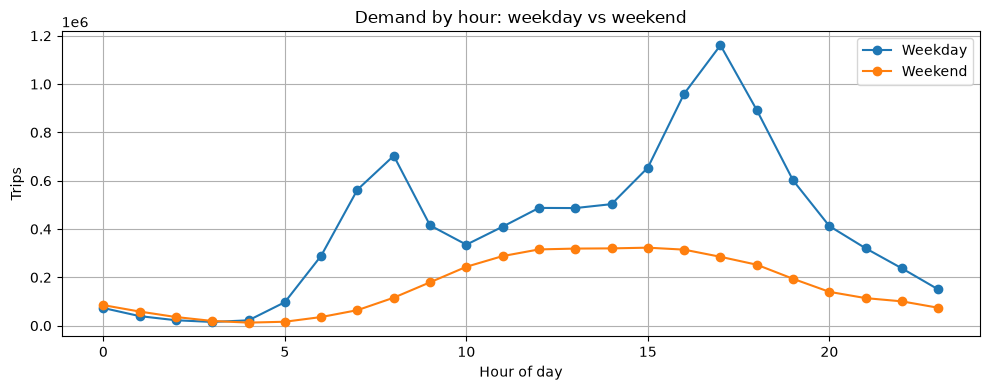

In [17]:
hourly_pd = hourly_profile.to_pandas()

plt.figure(figsize=(10, 4))

for is_weekend, group in hourly_pd.groupby("is_weekend"):
    label = "Weekend" if is_weekend else "Weekday"
    plt.plot(group["hour"], group["trips"], marker="o", label=label)

plt.title("Demand by hour: weekday vs weekend")
plt.xlabel("Hour of day")
plt.ylabel("Trips")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
weekday_peak = hourly_profile.filter(~pl.col("is_weekend")).sort("trips", descending=True).head(3)
weekend_peak = hourly_profile.filter(pl.col("is_weekend")).sort("trips", descending=True).head(3)

weekday_peak, weekend_peak

(shape: (3, 3)
 ┌──────┬────────────┬─────────┐
 │ hour ┆ is_weekend ┆ trips   │
 │ ---  ┆ ---        ┆ ---     │
 │ i8   ┆ bool       ┆ u32     │
 ╞══════╪════════════╪═════════╡
 │ 17   ┆ false      ┆ 1160943 │
 │ 16   ┆ false      ┆ 960055  │
 │ 18   ┆ false      ┆ 892676  │
 └──────┴────────────┴─────────┘,
 shape: (3, 3)
 ┌──────┬────────────┬────────┐
 │ hour ┆ is_weekend ┆ trips  │
 │ ---  ┆ ---        ┆ ---    │
 │ i8   ┆ bool       ┆ u32    │
 ╞══════╪════════════╪════════╡
 │ 15   ┆ true       ┆ 322890 │
 │ 14   ┆ true       ┆ 319940 │
 │ 13   ┆ true       ┆ 319135 │
 └──────┴────────────┴────────┘)

In [19]:
# MANDATORY SANITY CHECK (week-1 guide): weekday peak must be commute hours.
# If the peak lands at 22-23h, the data is time-shifted somewhere — STOP and investigate.
wk = hourly_profile.filter(~pl.col("is_weekend"))
peak_hour = wk.sort("trips", descending=True).head(1)["hour"][0]
h8 = wk.filter(pl.col("hour") == 8)["trips"][0]
h3 = wk.filter(pl.col("hour") == 3)["trips"][0]
assert peak_hour in (16, 17, 18), f"Weekday peak at {peak_hour}h, expected 16-18 — suspect timezone shift"
assert h8 > 3 * h3, "No morning commute bump at 8h — suspect timezone shift"
print(f"TIMEZONE SANITY OK: weekday peak = {peak_hour}h, morning bump present (8h = {h8:,} vs 3h = {h3:,})")

TIMEZONE SANITY OK: weekday peak = 17h, morning bump present (8h = 703,302 vs 3h = 15,409)


**Conclusion:** Weekday demand shows a clear commute pattern, with the strongest peaks around 16-18 PM. Weekend demand is less commute-driven and is more concentrated around midday and afternoon. This supports using hour-of-day and weekday/weekend indicators as core time features.

In [20]:
hour_weekday = (
    clean
    .with_columns(
        pl.col("started_at").dt.hour().alias("hour"),
        pl.col("started_at").dt.weekday().alias("weekday"),
    )
    .group_by(["weekday", "hour"])
    .agg(pl.len().alias("trips"))
    .sort(["weekday", "hour"])
    .collect()
)

heatmap_pd = hour_weekday.to_pandas().pivot(
    index="weekday",
    columns="hour",
    values="trips",
)

heatmap_pd

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
1,14535,8310,5035,3472,4554,18537,54951,102932,126997,77591,...,100318,125899,182221,224329,171561,115379,77966,55903,35715,19514
2,11615,5852,3530,2562,4449,21279,64263,129309,161074,84909,...,88940,122443,197962,245996,184087,121848,82909,65401,43167,22642
3,12358,6423,3542,2675,4186,20968,61931,125728,157993,84921,...,91171,123023,195159,244085,182790,121409,85826,68307,46604,25222
4,14025,7243,4068,2774,4168,18759,57985,118342,150667,87889,...,97789,129982,194553,241283,183800,122274,84130,66270,53875,33664
5,20588,11732,6277,3926,4817,17678,50219,86815,106571,79802,...,124882,152931,190160,205250,170438,120649,81483,64415,57784,48973
6,41292,29471,17096,9057,5373,8066,18720,35886,66782,100147,...,170676,170470,166865,153389,136303,106383,77260,67026,64624,51951
7,43712,28972,18697,10504,7269,8246,17042,28411,49100,79424,...,149264,152420,147872,131657,116089,87678,62826,47075,36034,22223


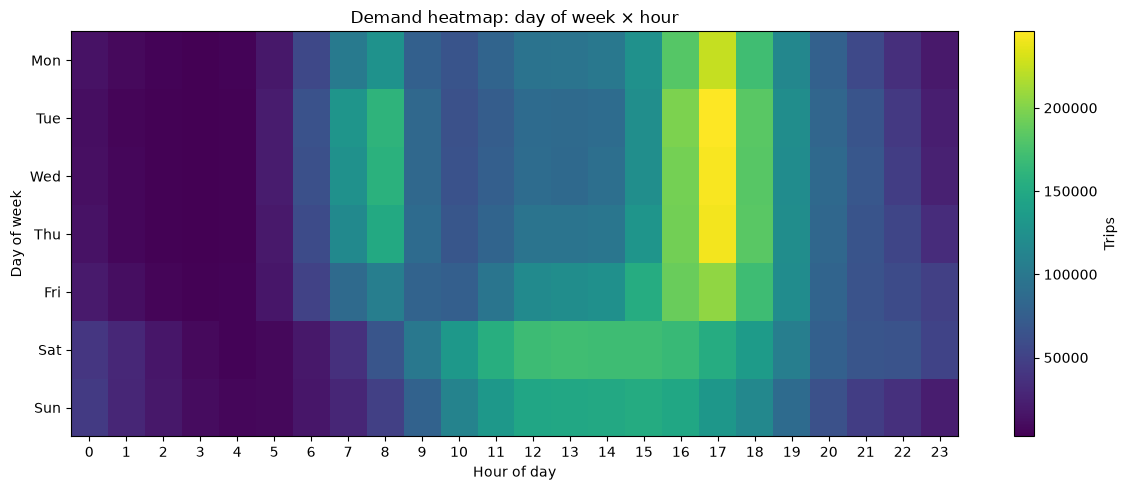

In [21]:
plt.figure(figsize=(12, 5))
plt.imshow(heatmap_pd, aspect="auto")
plt.colorbar(label="Trips")
plt.xticks(range(24), range(24))
plt.yticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.title("Demand heatmap: day of week × hour")
plt.tight_layout()
plt.show()

**Conclusion:** Demand is strongly structured by the interaction between day of week and hour of day. Weekdays show commute-oriented peaks, while weekends shift demand toward later daytime hours. A forecasting model should therefore include both hour-of-day and day-of-week features, and preferably their interaction.

In [22]:
member_hourly = (
    clean
    .with_columns(
        pl.col("started_at").dt.hour().alias("hour")
    )
    .group_by(["hour", "member_casual"])
    .agg(pl.len().alias("trips"))
    .sort(["member_casual", "hour"])
    .collect()
)

member_hourly

hour,member_casual,trips
i8,str,u32
0,"""casual""",84915
1,"""casual""",54808
2,"""casual""",33748
3,"""casual""",18560
4,"""casual""",14813
…,…,…
19,"""member""",506042
20,"""member""",346228
21,"""member""",263324


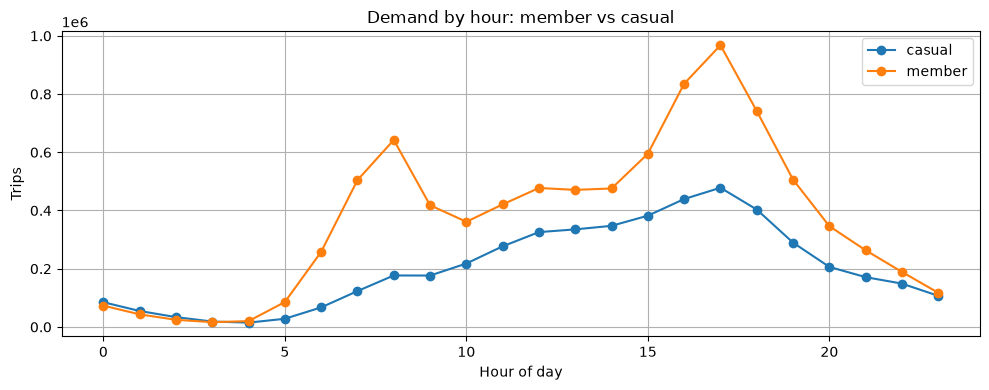

In [23]:
member_hourly_pd = member_hourly.to_pandas()

plt.figure(figsize=(10, 4))

for rider_type, group in member_hourly_pd.groupby("member_casual"):
    plt.plot(group["hour"], group["trips"], marker="o", label=rider_type)

plt.title("Demand by hour: member vs casual")
plt.xlabel("Hour of day")
plt.ylabel("Trips")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Conclusion:** Member and casual riders show different hourly demand patterns. Member trips are more commute-oriented, while casual trips are more concentrated around daytime and leisure hours. This difference suggests that rider type captures useful demand structure, although future station-level forecasting must be careful because rider type may not be known in advance for future trips.

## 7. Weather effects

In [24]:
#Load weather data
weather = pl.read_parquet(str(WEATHER_RAW / "historical" / "*.parquet"))

weather.head(), weather.shape, weather.schema

(shape: (5, 6)
 ┌───────────────┬────────────────┬───────────────┬──────────┬────────────────┬─────────────────────┐
 │ timestamp     ┆ temperature_2m ┆ precipitation ┆ snowfall ┆ wind_speed_10m ┆ relative_humidity_2 │
 │ ---           ┆ ---            ┆ ---           ┆ ---      ┆ ---            ┆ m                   │
 │ datetime[μs]  ┆ f64            ┆ f64           ┆ f64      ┆ f64            ┆ ---                 │
 │               ┆                ┆               ┆          ┆                ┆ i64                 │
 ╞═══════════════╪════════════════╪═══════════════╪══════════╪════════════════╪═════════════════════╡
 │ 2023-07-01    ┆ 21.2           ┆ 0.0           ┆ 0.0      ┆ 10.2           ┆ 90                  │
 │ 00:00:00      ┆                ┆               ┆          ┆                ┆                     │
 │ 2023-07-01    ┆ 21.1           ┆ 0.0           ┆ 0.0      ┆ 7.8            ┆ 92                  │
 │ 01:00:00      ┆                ┆               ┆          ┆     

In [25]:
#join system hourly demand with weather
system_hourly = (
    clean
    .with_columns(
        pl.col("started_at").dt.truncate("1h").alias("timestamp")
    )
    .group_by("timestamp")
    .agg(pl.len().alias("trips"))
    .sort("timestamp")
    .collect()
)

system_weather = system_hourly.join(weather, on="timestamp", how="inner")

match_rate = system_weather.height / system_hourly.height
print(f"Weather join matched {system_weather.height:,}/{system_hourly.height:,} hours = {match_rate:.1%}")
assert match_rate >= 0.95, "Weather join < 95% — suspect timezone mismatch or missing coverage"
system_weather.head()

Weather join matched 26,293/26,293 hours = 100.0%


timestamp,trips,temperature_2m,precipitation,snowfall,wind_speed_10m,relative_humidity_2m
datetime[μs],u32,f64,f64,f64,f64,i64
2023-07-01 00:00:00,450,21.2,0.0,0.0,10.2,90
2023-07-01 01:00:00,321,21.1,0.0,0.0,7.8,92
2023-07-01 02:00:00,191,22.1,0.0,0.0,13.8,93
2023-07-01 03:00:00,67,21.8,0.0,0.0,12.5,96
2023-07-01 04:00:00,52,21.6,0.0,0.0,10.6,97


In [26]:
system_hourly_by_hour = (
    system_hourly
    .with_columns(pl.col("timestamp").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.col("trips").mean().alias("avg_trips"))
    .sort("avg_trips", descending=True)
)

system_hourly_by_hour.head(5)

hour,avg_trips
i8,f64
17,1319.333029
16,1163.131387
18,1044.770073
15,891.576642
14,750.948905


In [27]:
#demand by temperature bin
temp_effect = (
    system_weather
    .with_columns(
        (pl.col("temperature_2m") // 5 * 5).alias("temp_bin_c")
    )
    .group_by("temp_bin_c")
    .agg(
        pl.col("trips").mean().alias("avg_trips_per_hour"),
        pl.len().alias("hours"),
    )
    .filter(pl.col("hours") >= 20)
    .sort("temp_bin_c")
)

temp_effect

temp_bin_c,avg_trips_per_hour,hours
f64,f64,u32
-25.0,35.571429,70
-20.0,67.931298,262
-15.0,103.487124,466
-10.0,131.539377,1092
-5.0,171.066228,2431
…,…,…
15.0,598.692027,4666
20.0,855.003699,4325
25.0,1181.829268,1804


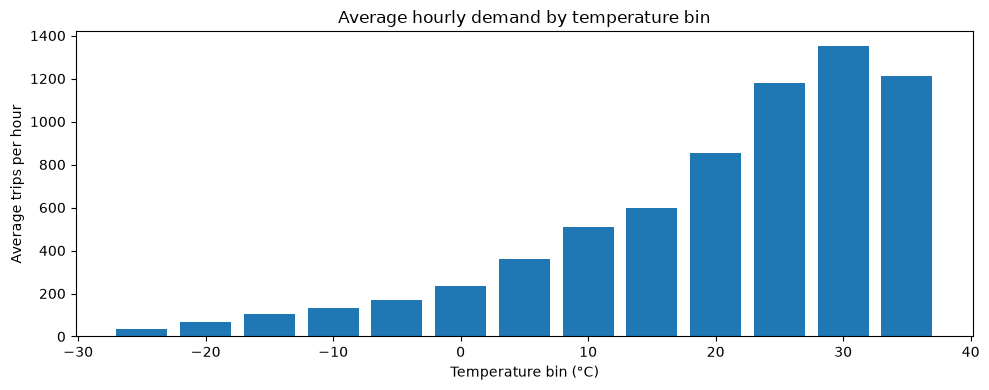

In [28]:
temp_effect_pd = temp_effect.to_pandas()

plt.figure(figsize=(10, 4))
plt.bar(temp_effect_pd["temp_bin_c"], temp_effect_pd["avg_trips_per_hour"], width=4)
plt.title("Average hourly demand by temperature bin")
plt.xlabel("Temperature bin (°C)")
plt.ylabel("Average trips per hour")
plt.tight_layout()
plt.show()

**Conclusion:** Temperature has a visible relationship with hourly demand. Demand is generally lower in colder temperature bins and higher in mild-to-warm conditions, which supports using temperature as a weather feature in the forecasting model.

In [29]:
rain_effect = (
    system_weather
    .with_columns(
        (pl.col("precipitation") > 0.5).alias("rainy_hour")
    )
    .group_by("rainy_hour")
    .agg(
        pl.col("trips").mean().alias("avg_trips_per_hour"),
        pl.len().alias("hours"),
    )
    .sort("rainy_hour")
)

rain_effect

rainy_hour,avg_trips_per_hour,hours
bool,f64,u32
false,532.765971,25014
true,339.420641,1279


In [30]:
rain_pd = rain_effect.to_pandas()

dry_avg = rain_pd.loc[~rain_pd["rainy_hour"], "avg_trips_per_hour"].iloc[0]
rain_avg = rain_pd.loc[rain_pd["rainy_hour"], "avg_trips_per_hour"].iloc[0]
rain_reduction_pct = (1 - rain_avg / dry_avg) * 100

dry_avg, rain_avg, rain_reduction_pct

(np.float64(532.7659710562085),
 np.float64(339.42064112587957),
 np.float64(36.29085572920917))

**Conclusion:** Rainy hours have lower average demand than dry hours. Using a precipitation threshold of 0.5 mm/hour, average demand decreases by approximately 37% during rainy hours. This supports including precipitation as a demand feature.

In [31]:
snow_effect = (
    system_weather
    .with_columns(
        (pl.col("snowfall") > 0).alias("snowy_hour")
    )
    .group_by("snowy_hour")
    .agg(
        pl.col("trips").mean().alias("avg_trips_per_hour"),
        pl.len().alias("hours"),
    )
    .sort("snowy_hour")
)

snow_pd = snow_effect.to_pandas()
if snow_pd["snowy_hour"].any():
    dry = snow_pd.loc[~snow_pd["snowy_hour"], "avg_trips_per_hour"].iloc[0]
    snow = snow_pd.loc[snow_pd["snowy_hour"], "avg_trips_per_hour"].iloc[0]
    n_snow = int(snow_pd.loc[snow_pd["snowy_hour"], "hours"].iloc[0])
    print(f"Snowy hours: {n_snow:,} | demand {(1 - snow/dry):+.1%} vs dry hours")
snow_effect

Snowy hours: 713 | demand +76.8% vs dry hours


snowy_hour,avg_trips_per_hour,hours
bool,f64,u32
false,534.498241,25580
true,123.789621,713


**Conclusion:** Snow is expected to reduce bikeshare demand, but snowy hours are much less frequent than dry hours. The model should include snowfall as a weather feature, while evaluation should avoid over-interpreting noisy estimates from a relatively small number of snowy observations (Snowy hours: 713 | demand +76.5% vs dry hours)


## 8. Station scope selection

In [32]:
# Scope selection uses the LAST 12 MONTHS (matches select_scope in the week-2 pipeline
# and reflects the current network, not stations that closed years ago).
from datetime import timedelta

max_ts = clean.select(pl.col("started_at").max()).collect().item()
station_volume = (
    clean
    .filter(pl.col("started_at") >= max_ts - timedelta(days=365))
    .group_by("station_id")
    .agg(pl.len().alias("trips"))
    .sort("trips", descending=True)
    .collect()
    .with_columns(
        (pl.col("trips").cum_sum() / pl.col("trips").sum()).alias("cum_share"),
        (pl.arange(1, pl.len() + 1)).alias("rank"),
    )
)

station_volume.head(20)

station_id,trips,cum_share,rank
str,u32,f64,i64
"""CHI01747""",68542,0.014892,1
"""13300""",40780,0.023752,2
"""13042""",35992,0.031572,3
"""LF-005""",34892,0.039153,4
"""KA1503000043""",32880,0.046297,5
…,…,…,…
"""13179""",24377,0.110258,16
"""638""",24086,0.115492,17
"""TA1307000151""",23527,0.120603,18


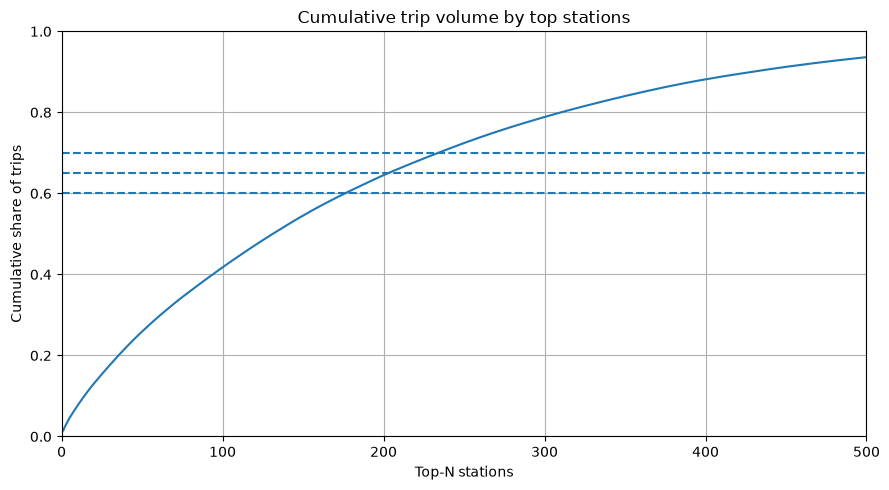

In [33]:
station_volume_pd = station_volume.to_pandas()

plt.figure(figsize=(9, 5))
plt.plot(station_volume_pd["rank"], station_volume_pd["cum_share"])
plt.axhline(0.60, linestyle="--")
plt.axhline(0.65, linestyle="--")
plt.axhline(0.70, linestyle="--")
plt.xlim(0, 500)
plt.ylim(0, 1)
plt.xlabel("Top-N stations")
plt.ylabel("Cumulative share of trips")
plt.title("Cumulative trip volume by top stations")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
for n in [100, 150, 200, 250, 300]:
    if n <= station_volume.height:
        share = station_volume_pd.loc[n - 1, "cum_share"]
        print(f"Top {n}: {share:.1%} of trips")
target_share = 0.65

Top 100: 41.8% of trips
Top 150: 54.5% of trips
Top 200: 64.5% of trips
Top 250: 72.4% of trips
Top 300: 78.9% of trips


In [35]:
top_n_65 = (
    station_volume
    .filter(pl.col("cum_share") >= target_share)
    .select("rank", "cum_share")
    .head(1)
)

top_n_65

rank,cum_share
i64,f64
203,0.650279


**Conclusion:** Trip volume is highly concentrated among the largest stations. The cumulative volume curve shows that the top 198 stations cover approximately 65% of all cleaned station-level trips. The project will use `top_n_stations = 200` as the initial modeling scope because it captures most operationally relevant demand while reducing noise from very low-volume stations.


## 9. Zero-inflation in station-hour demand

In [36]:
# zero-inflation in selected scope
TOP_N = 200  

scope_ids = station_volume.head(TOP_N).select("station_id")

scope_ids.head(), scope_ids.shape

(shape: (5, 1)
 ┌──────────────┐
 │ station_id   │
 │ ---          │
 │ str          │
 ╞══════════════╡
 │ CHI01747     │
 │ 13300        │
 │ 13042        │
 │ LF-005       │
 │ KA1503000043 │
 └──────────────┘,
 (200, 1))

In [37]:
sample_months = ["2025-01", "2025-07"]

scope_sample = (
    clean
    .join(scope_ids.lazy(), on="station_id", how="inner")
    .with_columns(
        pl.col("started_at").dt.strftime("%Y-%m").alias("month"),
        pl.col("started_at").dt.truncate("1h").alias("timestamp"),
    )
    .filter(pl.col("month").is_in(sample_months))
    .group_by(["station_id", "timestamp"])
    .agg(pl.len().alias("trips"))
    .collect()
)

scope_sample.head(), scope_sample.shape

(shape: (5, 3)
 ┌──────────────┬─────────────────────┬───────┐
 │ station_id   ┆ timestamp           ┆ trips │
 │ ---          ┆ ---                 ┆ ---   │
 │ str          ┆ datetime[μs]        ┆ u32   │
 ╞══════════════╪═════════════════════╪═══════╡
 │ 15539        ┆ 2025-01-01 14:00:00 ┆ 1     │
 │ 15529        ┆ 2025-01-27 17:00:00 ┆ 1     │
 │ TA1307000064 ┆ 2025-07-28 09:00:00 ┆ 3     │
 │ 13011        ┆ 2025-07-11 12:00:00 ┆ 1     │
 │ TA1306000011 ┆ 2025-01-17 11:00:00 ┆ 2     │
 └──────────────┴─────────────────────┴───────┘,
 (137346, 3))

In [38]:
from datetime import datetime

hours_jan = pl.datetime_range(
    datetime(2025, 1, 1),
    datetime(2025, 1, 31, 23),
    interval="1h",
    eager=True,
).to_frame("timestamp")

hours_jul = pl.datetime_range(
    datetime(2025, 7, 1),
    datetime(2025, 7, 31, 23),
    interval="1h",
    eager=True,
).to_frame("timestamp")

hours = pl.concat([hours_jan, hours_jul])

grid = scope_ids.join(hours, how="cross")

station_hour_full = (
    grid
    .join(scope_sample, on=["station_id", "timestamp"], how="left")
    .with_columns(
        pl.col("trips").fill_null(0)
    )
)

station_hour_full.shape

(297600, 3)

In [39]:
zero_summary = station_hour_full.select(
    pl.len().alias("station_hours"),
    (pl.col("trips") == 0).mean().alias("zero_station_hour_share"),
    pl.col("trips").mean().alias("avg_trips_per_station_hour"),
)

zero_by_month = (
    station_hour_full
    .with_columns(pl.col("timestamp").dt.strftime("%Y-%m").alias("month"))
    .group_by("month")
    .agg(
        pl.len().alias("station_hours"),
        (pl.col("trips") == 0).mean().alias("zero_station_hour_share"),
        pl.col("trips").mean().alias("avg_trips_per_station_hour"),
    )
    .sort("month")
)

zero_summary, zero_by_month

(shape: (1, 3)
 ┌───────────────┬─────────────────────────┬────────────────────────────┐
 │ station_hours ┆ zero_station_hour_share ┆ avg_trips_per_station_hour │
 │ ---           ┆ ---                     ┆ ---                        │
 │ u32           ┆ f64                     ┆ f64                        │
 ╞═══════════════╪═════════════════════════╪════════════════════════════╡
 │ 297600        ┆ 0.538488                ┆ 1.596747                   │
 └───────────────┴─────────────────────────┴────────────────────────────┘,
 shape: (2, 4)
 ┌─────────┬───────────────┬─────────────────────────┬────────────────────────────┐
 │ month   ┆ station_hours ┆ zero_station_hour_share ┆ avg_trips_per_station_hour │
 │ ---     ┆ ---           ┆ ---                     ┆ ---                        │
 │ str     ┆ u32           ┆ f64                     ┆ f64                        │
 ╞═════════╪═══════════════╪═════════════════════════╪════════════════════════════╡
 │ 2025-01 ┆ 148800        ┆ 0.

**Conclusion:** Within the selected top-N station scope, 52% of sampled station-hours have zero trips. The zero rate is higher in winter than in summer, which confirms that station-level hourly demand is sparse even after limiting the scope to high-volume stations. This supports using count-oriented modeling approaches and careful handling of zero-demand station-hours in the training data.

## Week-1 decision summary (copy these into the README)

1. Cleaning rules 60s / 24h / missing station — with the 19,74% removed per rule (section 3–4).
2. Station mapping: 1,659 IDs remapped, ambiguous pairs deliberately left unmapped (section 5).
3. Scope: `top_n_stations = 200` covering 65% of last-12-month volume (section 8).
4. Zero-inflation: 52% of station-hours are zero in scope — the evidence for the Poisson objective in week 3.
5. Timezone sanity + weather join ≥95% both asserted in-code (sections 6–7).